In [ ]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import joblib
from sklearn.metrics import r2_score
from src.utils import data_prediction

MODEL_DIR = ROOT / 'model'
OUTPUT_DIR = ROOT / 'output' / 'models_predict'

In [15]:
df_clustering = pd.read_csv(MODEL_DIR / 'SUPERSTORE_CLUSTERING.csv')

models_by_cluster = {}
for cluster in [0, 1, 2]:
    path = OUTPUT_DIR / f'cluster_{cluster}.joblib'
    models_by_cluster[cluster] = joblib.load(path)

dict_predict = data_prediction(df_clustering)

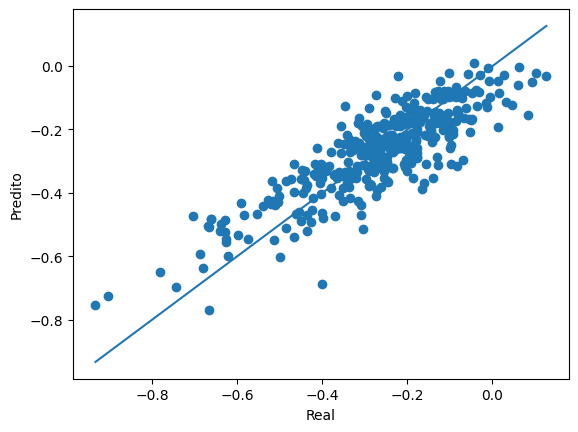

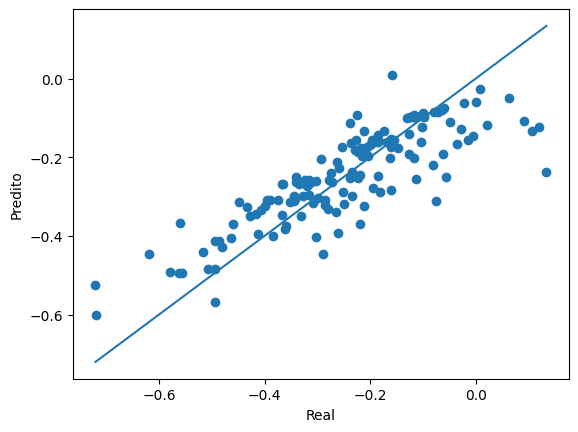

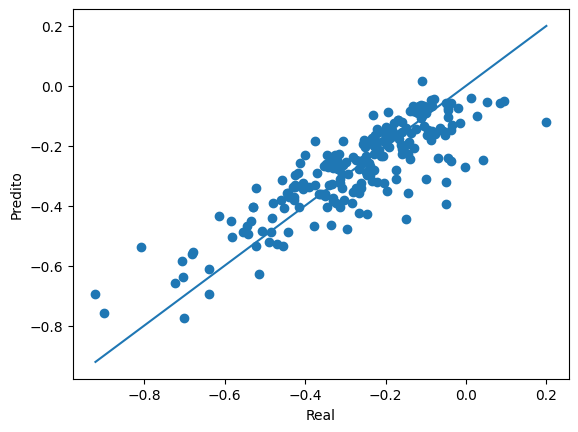

In [16]:
for cluster, df_cluster in dict_predict.items():
    model = models_by_cluster[cluster]

    X = df_cluster.drop(columns=['PROFIT_SCALED', 'CLUSTER'], errors='ignore')
    y_true = df_cluster['PROFIT_SCALED']

    # garantir consistência
    X = X[model.feature_names_in_]

    y_pred = model.predict(X)

    r2 = r2_score(y_true, y_pred)

    plt.figure()
    plt.scatter(y_true, y_pred)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel('Real')
    plt.ylabel('Predito')
    plt.show()